# Lab 10: Fashion MNIST

---
author: Your Name Here
date: December 6, 2024
embed-resources: true
---

## Introduction

## Methods

In [32]:
# standard imports
import matplotlib.pyplot as plt
import numpy as np
import random

# sklearn models
from sklearn.ensemble import RandomForestClassifier

# sklearn metrics
from sklearn.metrics import accuracy_score
# from sklearn.metrics import ConfusionMatrixDisplay

# pytorch imports
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

### Data

In [33]:
# load data
# download training data from open datasets
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# download test data from open datasets
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [34]:
# summary statistics
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [35]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


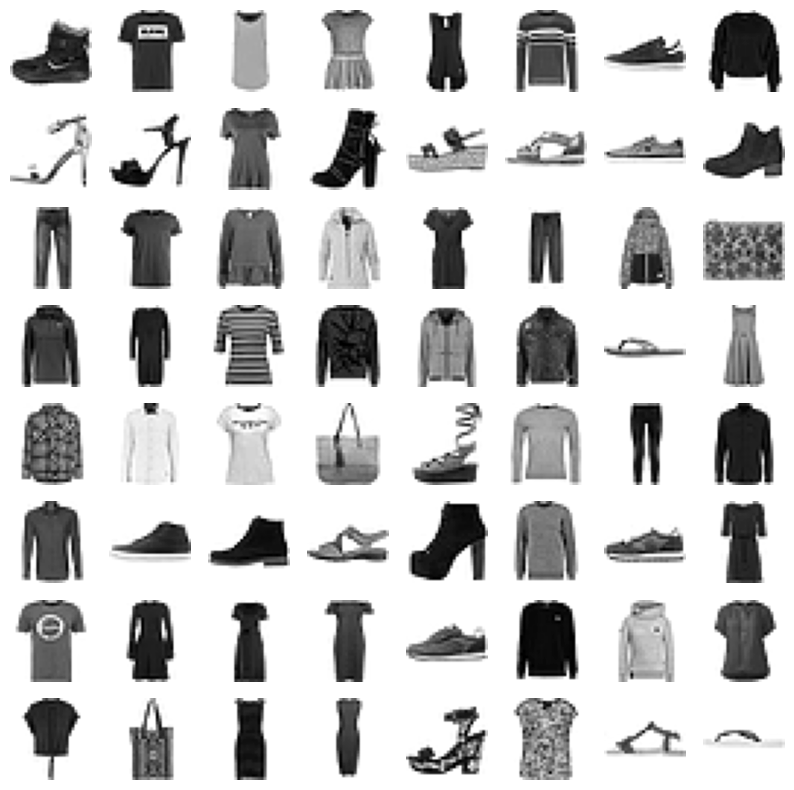

In [36]:
# visualizations

# Get a batch of training data
batch = next(iter(train_dataloader))
images, labels = batch

# Plot the first batch of images
fig, axs = plt.subplots(8, 8, figsize=(10, 10))
for i in range(8):
    for j in range(8):
        axs[i, j].set_axis_off()
        axs[i, j].imshow(images[i * 8 + j].squeeze(), cmap=plt.cm.gray_r)
plt.show()

### Models

In [37]:
# process data for ML

In [38]:
# get cpu, gpu or mps device for training
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device for training!")

Using mps device for training!


In [39]:
# define cnn model
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 10),
        )

    def forward(self, x):
        logits = self.conv_stack(x)
        return logits


model_cnn = ConvNet().to(device)
print(model_cnn)

ConvNet(
  (conv_stack): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=10, bias=True)
  )
)


In [ ]:
# define loss function
loss_fn = nn.CrossEntropyLoss()

# define cnn optimizer
optimizer_cnn = torch.optim.Adam(
    model_cnn.parameters(),
    lr=0.001,
)

In [42]:
# define train loop
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [43]:
# define test loop
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [46]:
# train model
epochs = 15
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_cnn, loss_fn, optimizer_cnn)
    test(test_dataloader, model_cnn, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.292731  [   64/60000]
loss: 0.653793  [ 6464/60000]
loss: 0.280180  [12864/60000]
loss: 0.495604  [19264/60000]
loss: 0.488262  [25664/60000]
loss: 0.481850  [32064/60000]
loss: 0.316356  [38464/60000]
loss: 0.527076  [44864/60000]
loss: 0.425798  [51264/60000]
loss: 0.349880  [57664/60000]
Test Error: 
 Accuracy: 87.1%, Avg loss: 0.360338 

Epoch 2
-------------------------------
loss: 0.230332  [   64/60000]
loss: 0.314633  [ 6464/60000]
loss: 0.197124  [12864/60000]
loss: 0.343841  [19264/60000]
loss: 0.334899  [25664/60000]
loss: 0.421788  [32064/60000]
loss: 0.265700  [38464/60000]
loss: 0.435964  [44864/60000]
loss: 0.322888  [51264/60000]
loss: 0.272938  [57664/60000]
Test Error: 
 Accuracy: 88.0%, Avg loss: 0.330135 

Epoch 3
-------------------------------
loss: 0.210230  [   64/60000]
loss: 0.261021  [ 6464/60000]
loss: 0.160888  [12864/60000]
loss: 0.287458  [19264/60000]
loss: 0.311048  [25664/60000]
loss: 0.384965  [32064/600

## Results

In [47]:
# report model metrics

## Discussion

### Conclusion

In [ ]:
# convert the convolutional neural network to TorchScript
model_scripted = torch.jit.script(model_cnn)
# write to disk
model_scripted.save("fashion-mnist.pt")